# Style Analysis of Adam Mickiewicz's Works

This notebook summarizes the statistics and visualizations produced by the `analyzer` package.
We analyze the Polish dictionary, the works of Adam Mickiewicz (our chosen "Master"), and compare
his writing style against another author using a custom similarity criterion.

In [ ]:
import matplotlib.pyplot as plt
from analyzer.data_processing import load_dictionary, get_dictionary_stats
from analyzer.text_analysis import get_works_stats, get_word_counter_for_file, find_missing_words
from analyzer.stats import get_top_n_words
from analyzer.similarity import calculate_cosine_similarity

DICTIONARY_PATH = "odm.txt"
WORKS_FILES = ["text1.txt", "text2.txt", "dziady.txt"] 

## 1. Dictionary Statistics

Before analyzing the Master's works, we first examine the structure of the Polish dictionary itself:
total lines, total word forms, unique word forms, and the most frequent letters and characters.

In [2]:
dict_stats = get_dictionary_stats(DICTIONARY_PATH)

print(f"Total lines: {dict_stats['lines']}")
print(f"Total word forms: {dict_stats['total_words']}")
print(f"Unique word forms: {dict_stats['unique_words']}")

print("\nTop words with most occurrences (including ties):")
for word, freq in dict_stats['top_words']:
    print(f"  - {word}: {freq} times")

Total lines: 236006
Total word forms: 4760935
Unique word forms: 4565466

Top words with most occurrences (including ties):
  - dziadzie: 7 times
  - kurze: 7 times
  - Aleksandrowie: 6 times
  - Franie: 6 times
  - Fredzie: 6 times
  - kicie: 6 times
  - kole: 6 times
  - macie: 6 times
  - mule: 6 times
  - porośli: 6 times


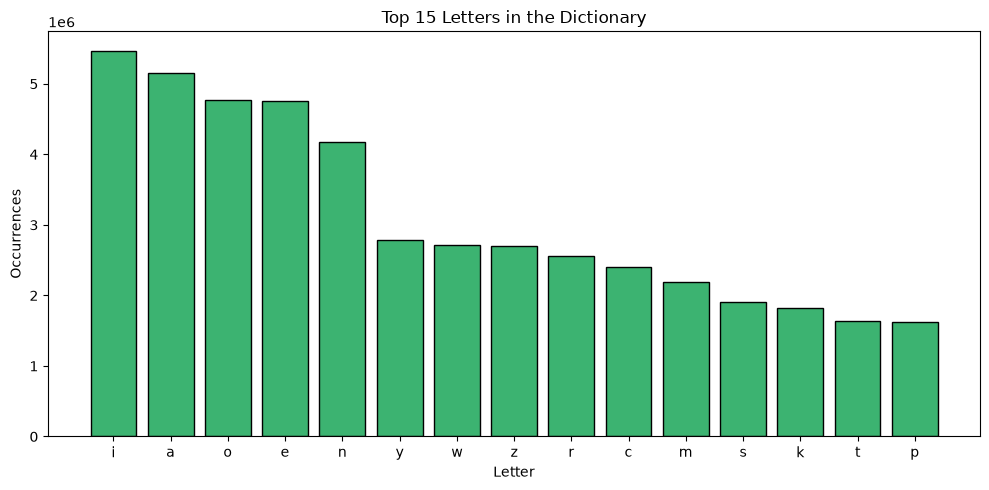

In [3]:
letters, letter_freqs = zip(*dict_stats['letters'][:15])

plt.figure(figsize=(10, 5))
plt.bar(letters, letter_freqs, color='mediumseagreen', edgecolor='black')
plt.title("Top 15 Letters in the Dictionary")
plt.xlabel("Letter")
plt.ylabel("Occurrences")
plt.tight_layout()
plt.show()

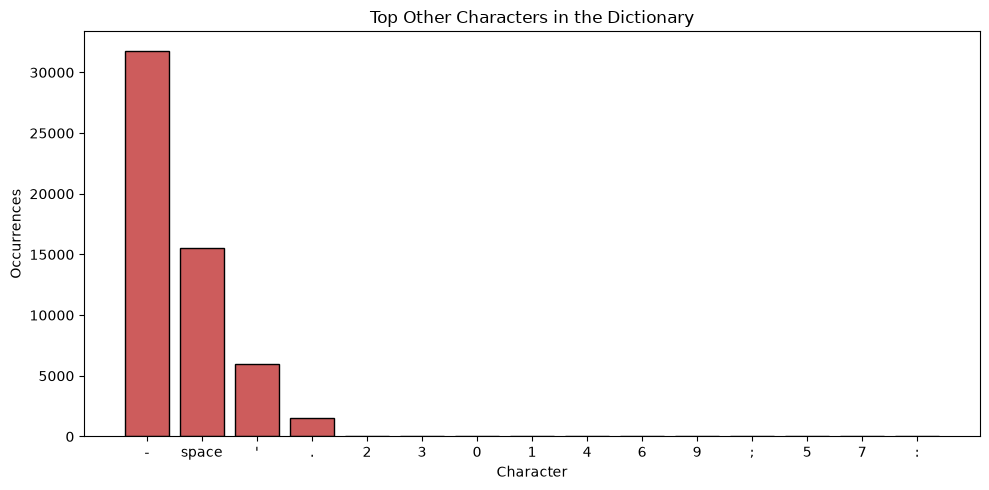

In [4]:
if dict_stats['other_chars']:
    other_chars, other_freqs = zip(*dict_stats['other_chars'][:15])
    labels = [c if c.strip() else f"space" for c in other_chars]

    plt.figure(figsize=(10, 5))
    plt.bar(labels, other_freqs, color='indianred', edgecolor='black')
    plt.title("Top Other Characters in the Dictionary")
    plt.xlabel("Character")
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()
else:
    print("No non-letter characters found in the dictionary.")

## 2. Statistics of the Master's Works

Now we examine each of Mickiewicz's works individually, and the combined statistics across all files.

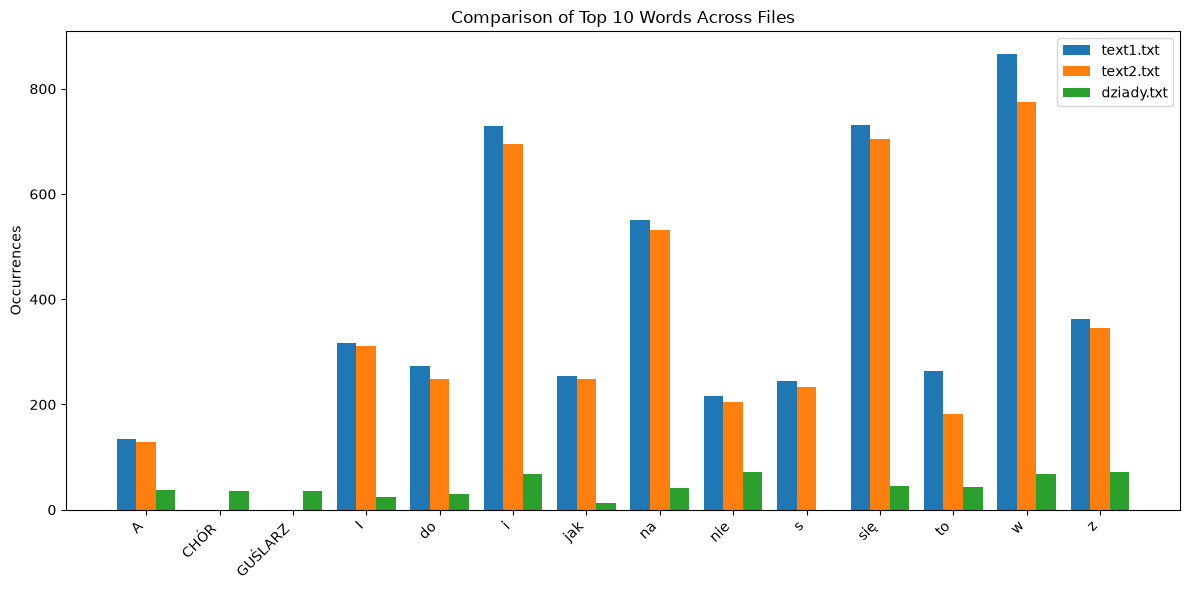

In [ ]:
N = 10

# build per-file statistics dict (needed for top_words) and word counters (needed for actual frequencies)
work_stats = {f: get_works_stats(f) for f in WORKS_FILES}
counters = {f: get_word_counter_for_file(f) for f in WORKS_FILES}

top_words_per_file = {}
all_top_words = set()

for file_path, stats in work_stats.items():
    top_n = stats['top_words'][:N]
    words_only = [word for word, _ in top_n]
    top_words_per_file[file_path] = words_only
    all_top_words.update(words_only)

all_top_words = sorted(all_top_words)

x = np.arange(len(all_top_words))
bar_width = 0.8 / len(WORKS_FILES)

plt.figure(figsize=(12, 6))

for i, file_path in enumerate(WORKS_FILES):
    counter = counters[file_path]
    freqs = [counter.get(word, 0) for word in all_top_words]
    offset = (i - len(WORKS_FILES) / 2) * bar_width + bar_width / 2
    plt.bar(x + offset, freqs, width=bar_width, label=file_path)

plt.xticks(x, all_top_words, rotation=45, ha='right')
plt.ylabel("Occurrences")
plt.title(f"Comparison of Top {N} Words Across Files")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
if len(WORKS_FILES) > 1:
    total_stats = get_works_stats(WORKS_FILES)

    print("--- Combined statistics for all works ---")
    print(f"Total lines: {total_stats['lines']}")
    print(f"Total words: {total_stats['total_words']}")
    print(f"Unique words: {total_stats['unique_words']}")
    print("Top 10 most frequent words overall:")
    for word, freq in total_stats['top_words']:
        print(f"  - {word}: {freq} times")

--- Combined statistics for all works ---
Total lines: 11832
Total words: 70248
Unique words: 14517
Top 10 most frequent words overall:
  - w: 1709 times
  - i: 1493 times
  - się: 1482 times
  - na: 1123 times
  - z: 780 times
  - I: 653 times
  - do: 553 times
  - jak: 516 times
  - nie: 494 times
  - to: 488 times


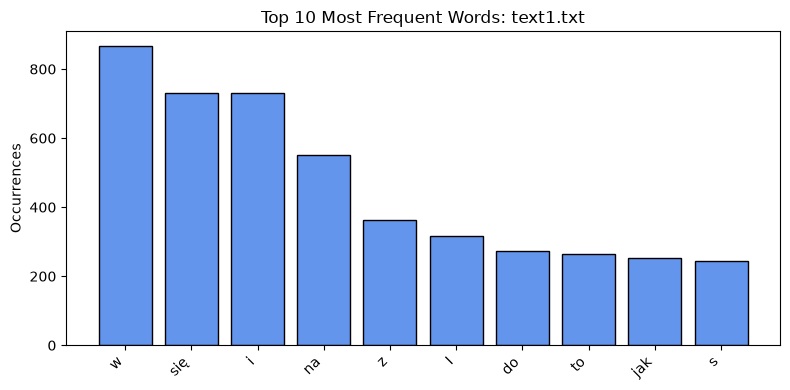

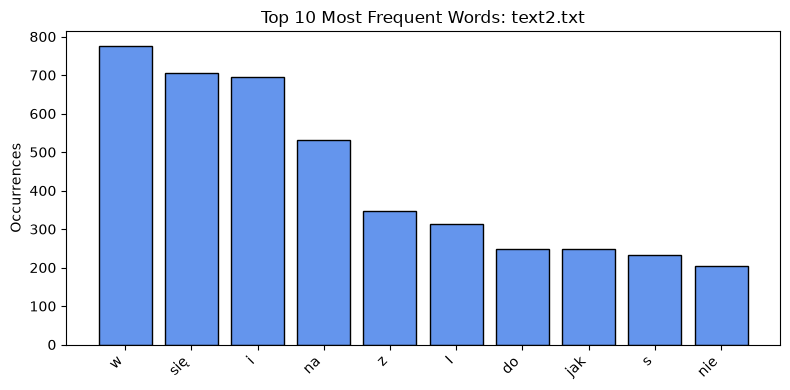

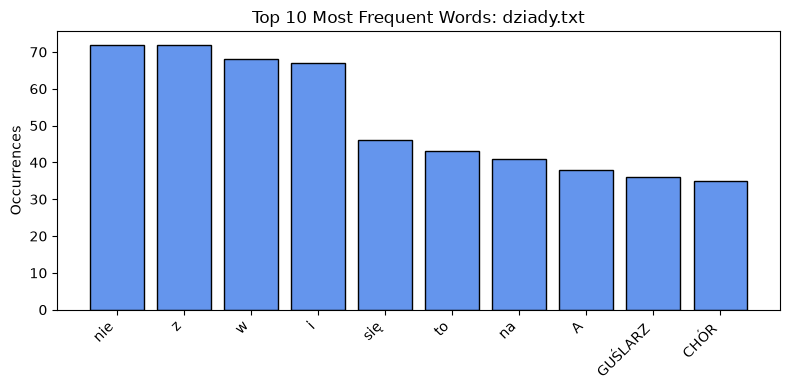

In [10]:
for file_path, stats in work_stats.items():
    words, freqs = zip(*stats['top_words'][:10])

    plt.figure(figsize=(8, 4))
    plt.bar(words, freqs, color='cornflowerblue', edgecolor='black')
    plt.title(f"Top 10 Most Frequent Words: {file_path}")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()

## 3. Words Not Found in the Dictionary

Here we identify words used in the Master's works that do not appear in the current Polish dictionary.
These may include archaic forms, proper nouns, or words specific to 19th-century usage.

In [11]:
dictionary_words = load_dictionary(DICTIONARY_PATH)
missing_words = find_missing_words(WORKS_FILES, dictionary_words)

print(f"Total unique missing words: {len(missing_words)}")
print(f"Total occurrences of missing words: {sum(freq for _, freq in missing_words)}")
print("\nTop 20 missing words:")
for word, freq in missing_words[:20]:
    print(f"  - {word}: {freq} times")

Total unique missing words: 2079
Total occurrences of missing words: 6176

Top 20 missing words:
  - the: 172 times
  - of: 115 times
  - jéj: 98 times
  - Project: 85 times
  - tém: 76 times
  - you: 57 times
  - Assessor: 50 times
  - with: 46 times
  - Str: 44 times
  - work: 44 times
  - this: 39 times
  - téj: 39 times
  - potém: 38 times
  - niéj: 36 times
  - Potém: 32 times
  - works: 32 times
  - nakształt: 30 times
  - zwolna: 28 times
  - electronic: 27 times
  - are: 25 times


In [16]:
dictionary_words = load_dictionary(DICTIONARY_PATH)

missing_words_per_file = {}

for file_path in WORKS_FILES:
    missing_words = find_missing_words(file_path, dictionary_words)
    missing_words_per_file[file_path] = missing_words

    print(f"\n--- {file_path} ---")
    print(f"Total unique missing words: {len(missing_words)}")
    print(f"Total occurrences of missing words: {sum(freq for _, freq in missing_words)}")
    print("Top 20 missing words:")
    for word, freq in missing_words[:5]:
        print(f"  - {word}: {freq} times")


--- text1.txt ---
Total unique missing words: 2027
Total occurrences of missing words: 4130
Top 20 missing words:
  - the: 172 times
  - of: 114 times
  - Project: 85 times
  - you: 57 times
  - jéj: 49 times

--- text2.txt ---
Total unique missing words: 1329
Total occurrences of missing words: 1971
Top 20 missing words:
  - jéj: 49 times
  - tém: 38 times
  - Assessor: 25 times
  - potém: 19 times
  - téj: 19 times

--- dziady.txt ---
Total unique missing words: 60
Total occurrences of missing words: 75
Top 20 missing words:
  - Szarpajmy: 7 times
  - wolnelektury: 4 times
  - Poema: 2 times
  - are: 2 times
  - daléj: 2 times


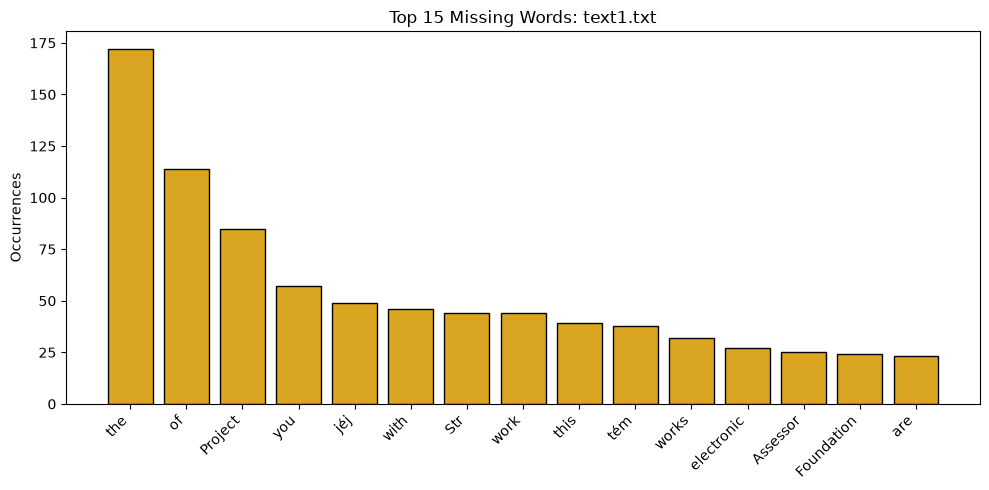

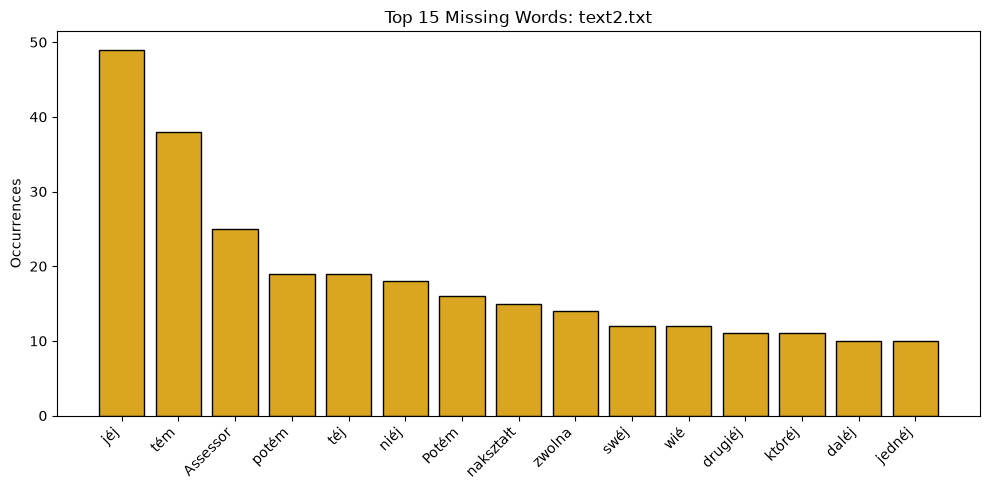

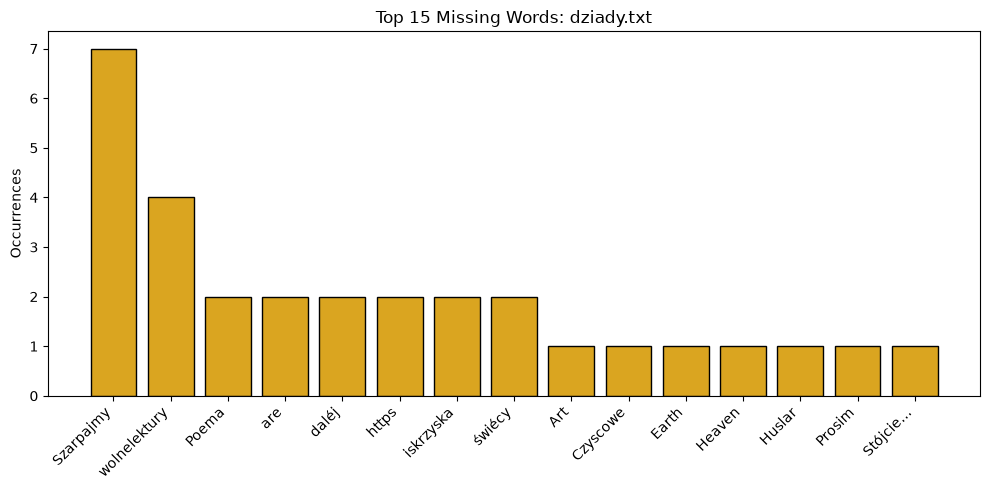

In [15]:
for file_path, missing_words in missing_words_per_file.items():
    top_missing = missing_words[:15]
    if not top_missing:
        print(f"No missing words in {file_path}")
        continue

    words, freqs = zip(*top_missing)

    plt.figure(figsize=(10, 5))
    plt.bar(words, freqs, color='goldenrod', edgecolor='black')
    plt.title(f"Top 15 Missing Words: {file_path}")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()

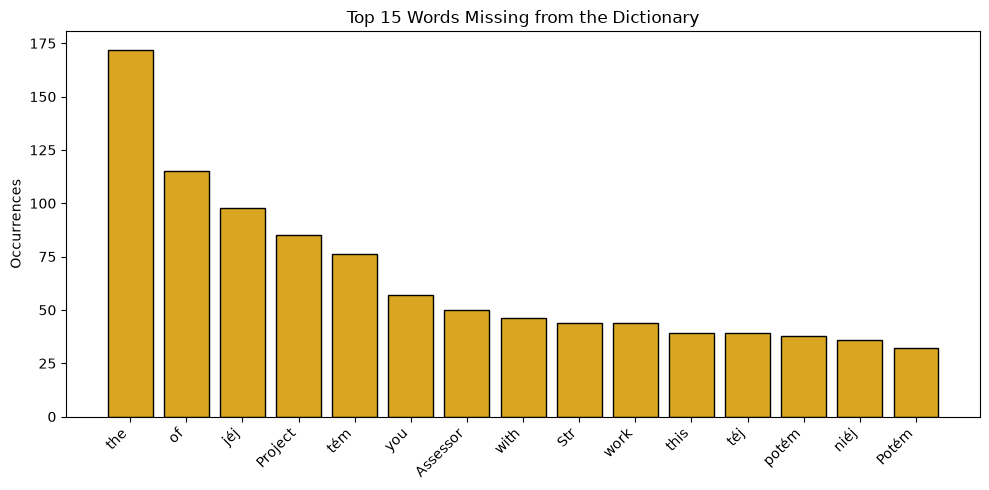

In [12]:
top_missing = missing_words[:15]
if top_missing:
    words, freqs = zip(*top_missing)

    plt.figure(figsize=(10, 5))
    plt.bar(words, freqs, color='goldenrod', edgecolor='black')
    plt.title("Top 15 Words Missing from the Dictionary")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()
else:
    print("No missing words found.")

## 4. N Most Frequent Words per File (`--frequencies`)

This corresponds to the `--frequencies` command-line option: for each work, we calculate
the n most frequent words. These frequency profiles form the basis of our style similarity criterion
described in the next section.

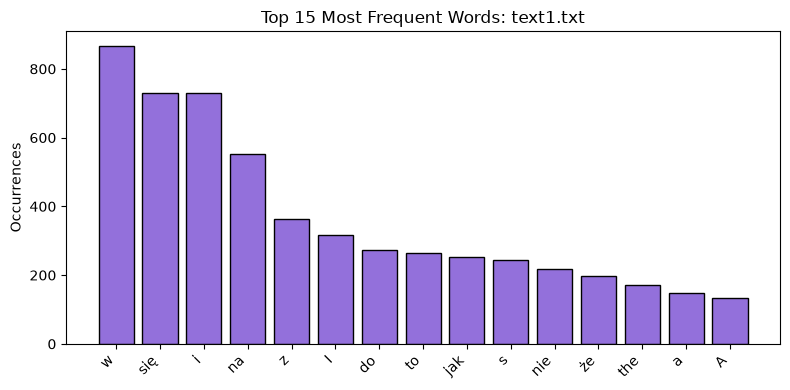

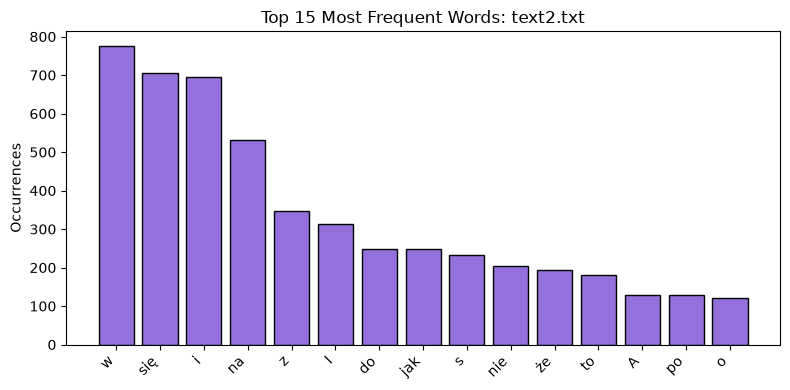

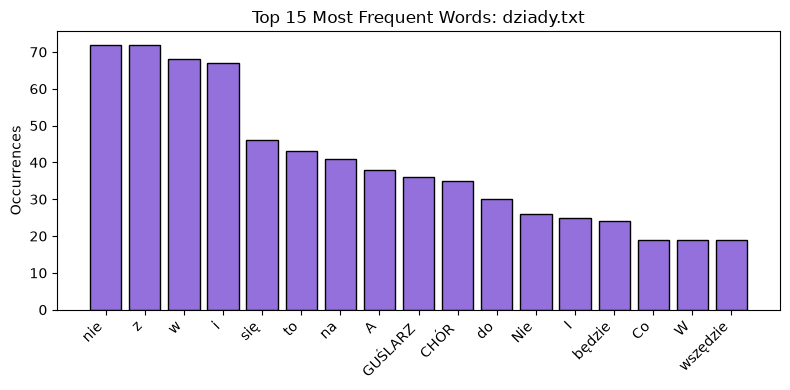

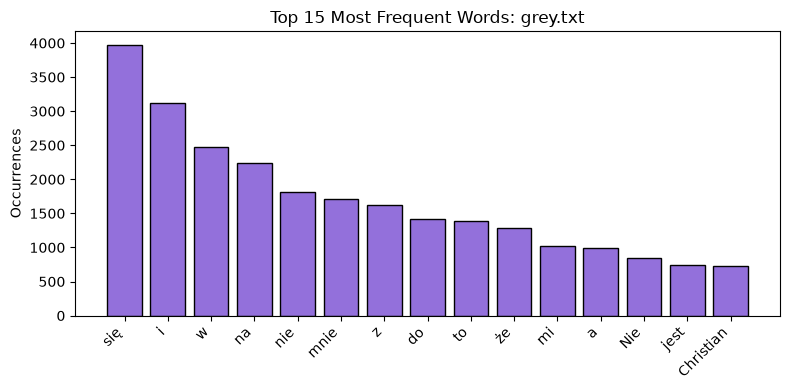

In [3]:
N = 15  # adjust as needed

counters = {f: get_word_counter_for_file(f) for f in WORKS_FILES}

for file_path, counter in counters.items():
    top_n = get_top_n_words(counter, N)
    words, freqs = zip(*top_n)

    plt.figure(figsize=(8, 4))
    plt.bar(words, freqs, color='mediumpurple', edgecolor='black')
    plt.title(f"Top {N} Most Frequent Words: {file_path}")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()

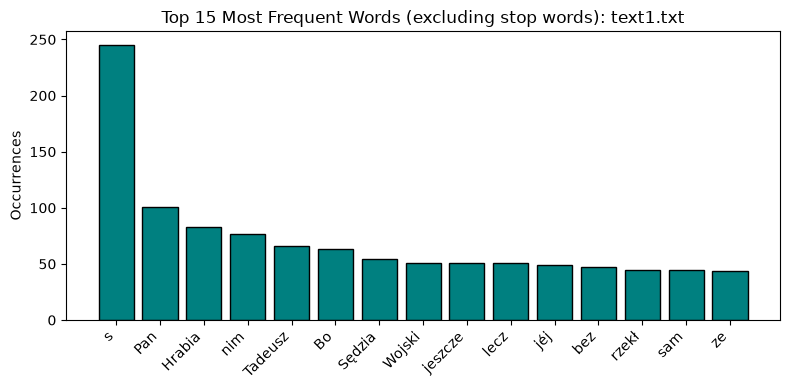

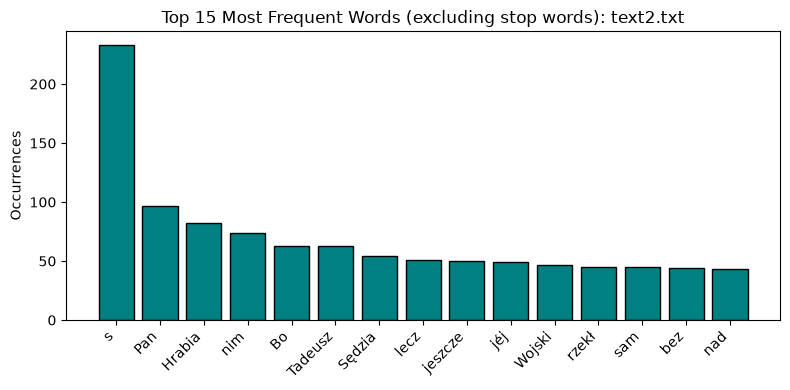

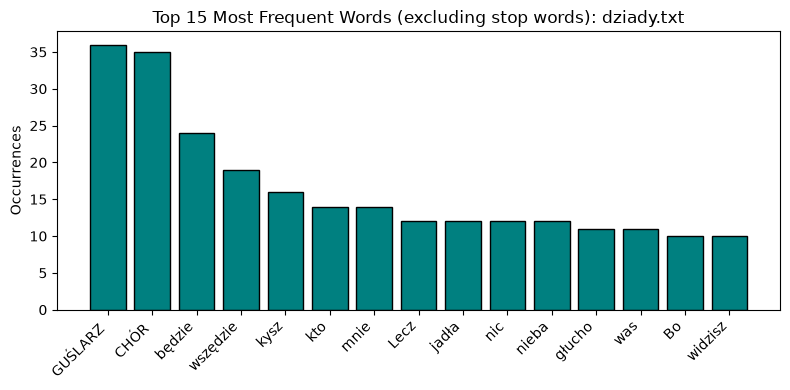

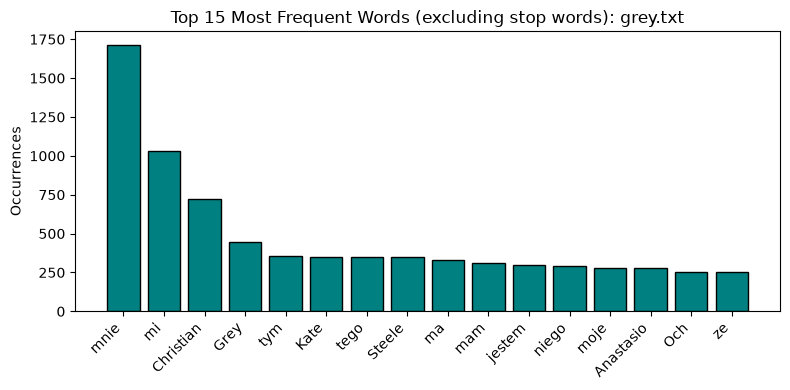

In [4]:
from collections import Counter
from analyzer.similarity import stop_words
N = 15  # adjust as needed

# same stop words list as used in calculate_cosine_similarity

for file_path, counter in counters.items():
    # filter out stop words before computing top-N
    filtered_counter = Counter({word: freq for word, freq in counter.items() if word.lower() not in stop_words})

    top_n = get_top_n_words(filtered_counter, N)
    words, freqs = zip(*top_n)

    plt.figure(figsize=(8, 4))
    plt.bar(words, freqs, color='teal', edgecolor='black')
    plt.title(f"Top {N} Most Frequent Words (excluding stop words): {file_path}")
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Occurrences")
    plt.tight_layout()
    plt.show()

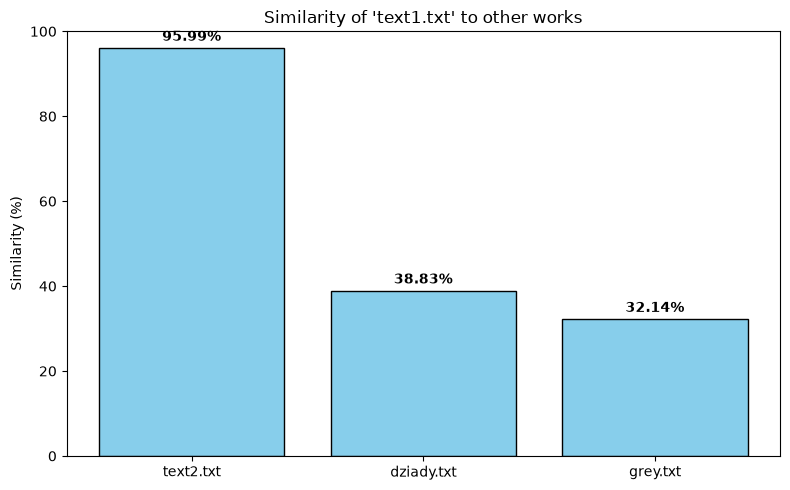

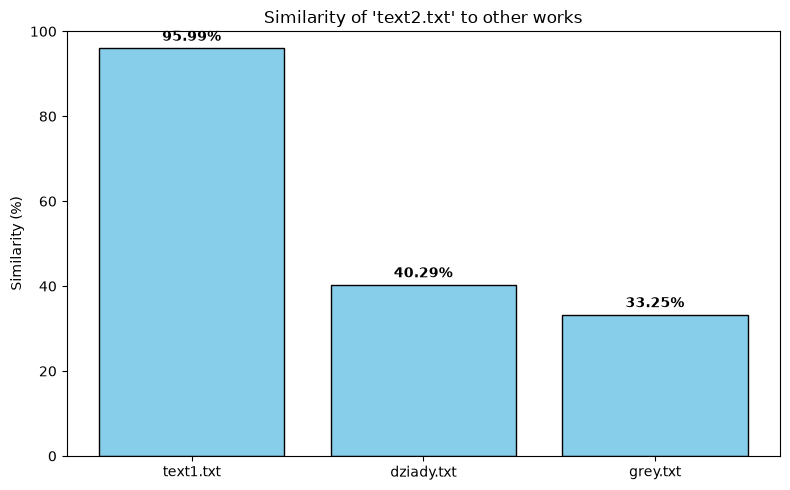

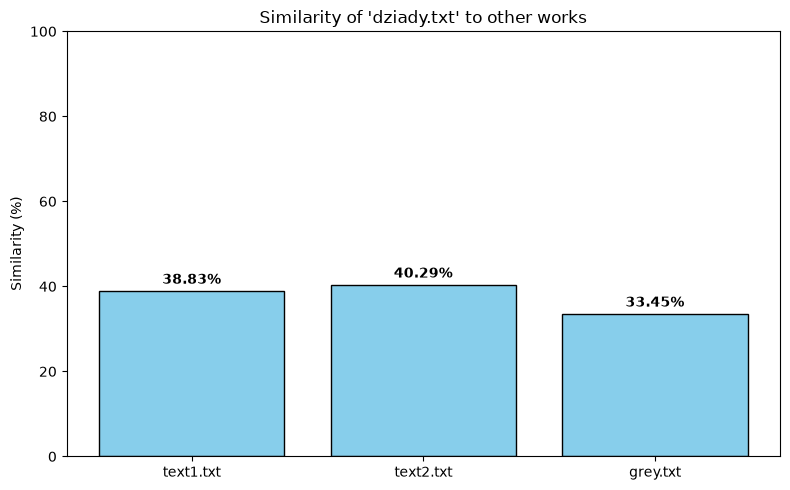

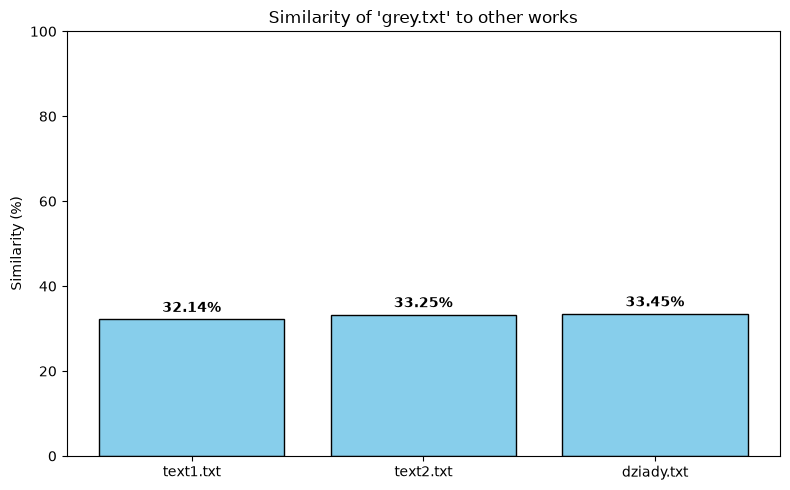

In [5]:
import matplotlib.pyplot as plt
from analyzer.text_analysis import get_word_counter_for_file
from analyzer.similarity import calculate_cosine_similarity

# list of your 4 text files
files = ["text1.txt", "text2.txt", "dziady.txt", "grey.txt"]

# generate word counters for all files to avoid recalculating
counters = {}
for file in files:
    counters[file] = get_word_counter_for_file(file)

# loop through each file and compare it to the rest
for base_file in files:
    other_files = []
    similarities = []
    
    # compare base_file with every other file
    for other_file in files:
        if base_file != other_file:
            score = calculate_cosine_similarity(counters[base_file], counters[other_file])
            other_files.append(other_file)
            similarities.append(score)
            
    # setup the bar chart
    plt.figure(figsize=(8, 5))
    bars = plt.bar(other_files, similarities, color='skyblue', edgecolor='black')
    
    # customize the look
    plt.title(f"Similarity of '{base_file}' to other works")
    plt.ylabel("Similarity (%)")
    plt.ylim(0, 100) # strict 0-100 scale as required
    
    # add exact percentage text above each bar
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{height}%', ha='center', va='bottom', fontweight='bold')
        
    # display the chart
    plt.tight_layout()
    plt.show()